# Gaussian Quadrature
All the other methods use "evenly spaced" points. Gaussian Quadrature asks: "What if we optimally chose exactly where the points should be to get the most accurate result mathematically possible?"
Using Legendre polynomials, it calculates the perfect specific locations to check the function, and the perfect specific weights to multiply them by.

### The Math
Gaussian quadrature calculates the integral over the standard interval $[-1, 1]$ as a weighted sum:
$$ \int_{-1}^1 f(t) dt \approx \sum_{i=1}^n c_i f(t_i) $$
where $t_i$ are the roots of the $n$-th Legendre polynomial and $c_i$ are their corresponding weights.

To integrate over an arbitrary interval $[a, b]$, we use a simple linear transformation $x = \frac{b-a}{2}t + \frac{b+a}{2}$ to shift the points into our window, and scale the final result by $\frac{b-a}{2}$:
$$ \int_a^b f(x) dx \approx \frac{b-a}{2} \sum_{i=1}^n c_i f\left( \frac{b-a}{2}t_i + \frac{b+a}{2} \right) $$

In [1]:
import numpy as np

def f(x):
    return np.exp(-x**2 / 2)

def gaussian_quadrature(f, a, b, n):
    # NumPy has a built-in function to generate the perfect optimal points (t) and their weights (c)
    t, c = np.polynomial.legendre.leggauss(n)
    
    # The points it gives are from -1 to 1. We have to map them to our actual interval [a, b]
    mapped_x = 0.5 * (b - a) * t + 0.5 * (b + a)
    
    # Multiply the weights by our function evaluated at those perfect points
    area = 0.5 * (b - a) * np.sum(c * f(mapped_x))
    return area

# Example usage (Notice how accurate it is with just 4 points!)
print("Gaussian Quadrature (4 points):", gaussian_quadrature(f, -1, 1, 4))


Gaussian Quadrature (4 points): 1.71122450459949


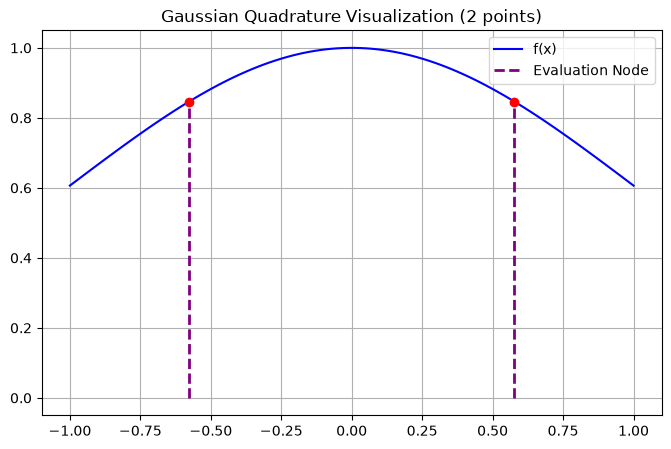

In [2]:
import matplotlib.pyplot as plt
import numpy as np
x_fine = np.linspace(-1, 1, 100)
y_fine = f(x_fine)
nodes = [-0.5773502691896257, 0.5773502691896257]
y_nodes = [f(x) for x in nodes]
plt.figure(figsize=(8, 5))
plt.plot(x_fine, y_fine, 'b-', label='f(x)')
for i in range(2):
    plt.vlines(nodes[i], 0, y_nodes[i], color='purple', linestyles='dashed', linewidth=2, label='Evaluation Node' if i==0 else '')
plt.plot(nodes, y_nodes, 'ro')
plt.title('Gaussian Quadrature Visualization (2 points)')
plt.legend()
plt.grid(True)
plt.show()
